In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Function to compute the loss given the predictor data
def compute_loss(W):
    return np.cos(W) * np.exp(-W/10)
    

In [4]:
# Generate data for performing the gradient descent

# Get 500 weights from -15 to 15 (inclusive)
w = np.linspace(-15, 15, 500)

# Get the loss of the weights generated above using 
# the function compute_loss
loss = compute_loss(w)


Text(0, 0.5, '$Loss$')

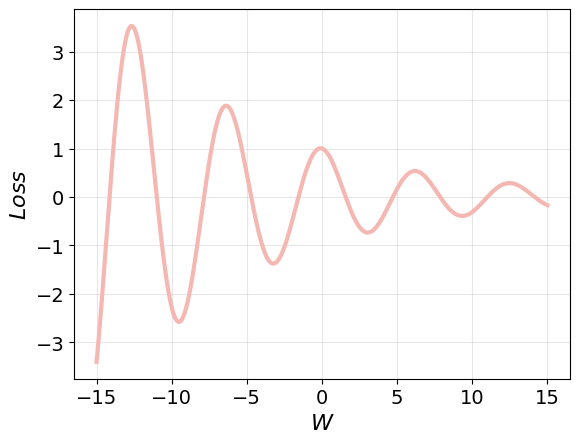

In [5]:
# Plot the generated data using the helper code given below
plt.plot(w, loss, linewidth=3, color='#F5B7B1')
plt.grid(alpha=0.3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('$W$', fontsize=16)
plt.ylabel('$Loss$', fontsize=16)


**loss function**
$$L(W) = \cos(W)e^{-\frac{W}{10}}$$

<img src="Equation%20by%20hand/WhatsApp%20Image%202026-06-02%20at%2014.12.43.jpeg" width="400" />

**Derivative of loss function L'(w) chain rule and product rule-- Gradient**  
$$\frac{dL}{dW} = -e^{-W/10} \left( \sin(W) + \frac{\cos(W)}{10} \right)$$



In [6]:
# Write the function to compute the derivative
def derivative(weight):
    return (-np.exp(-weight/10)/10)*(np.cos(weight)+(10*np.sin(weight)))

In [7]:
# Function to perform gradient descent
# This function takes 3 values, the weights, 
# the learning rate eta and a tolerance
def gradient_descent(W, eta=0.001, tolerance=0.000001):

    # Variable to store the W value before update. 
    # This will help to check for convergence. 
    W_prev = 0 
    
    # t is an iteration counter to compute the number of steps 
    t = 0

    # Save the current weights to a new list and 
    # append the updated weights in each iteration to the same
    Ws = [W]
    
    # Perform the update until convergence
    # Convergence is said to have taken place if 
    # the absolute difference between the previous and 
    # updated weight is less than the tolerance

    while (np.abs(W_prev-W)> tolerance):
        
        # Increment the counter t for each iteration
        t=t+1
        
        # Compute the gradient of W by calling the derivative function
        g = derivative(W)    
        
        # Save the W value in W_prev before the update for convergence test
        W_prev = W                          
        
        # Update the weight parameters based on the equation 
        # given in the instructions
        W = W_prev - (eta*g)
        
        # Append the new weight list with the udpated weight value
        Ws.append(W)
        
    return Ws, t
    

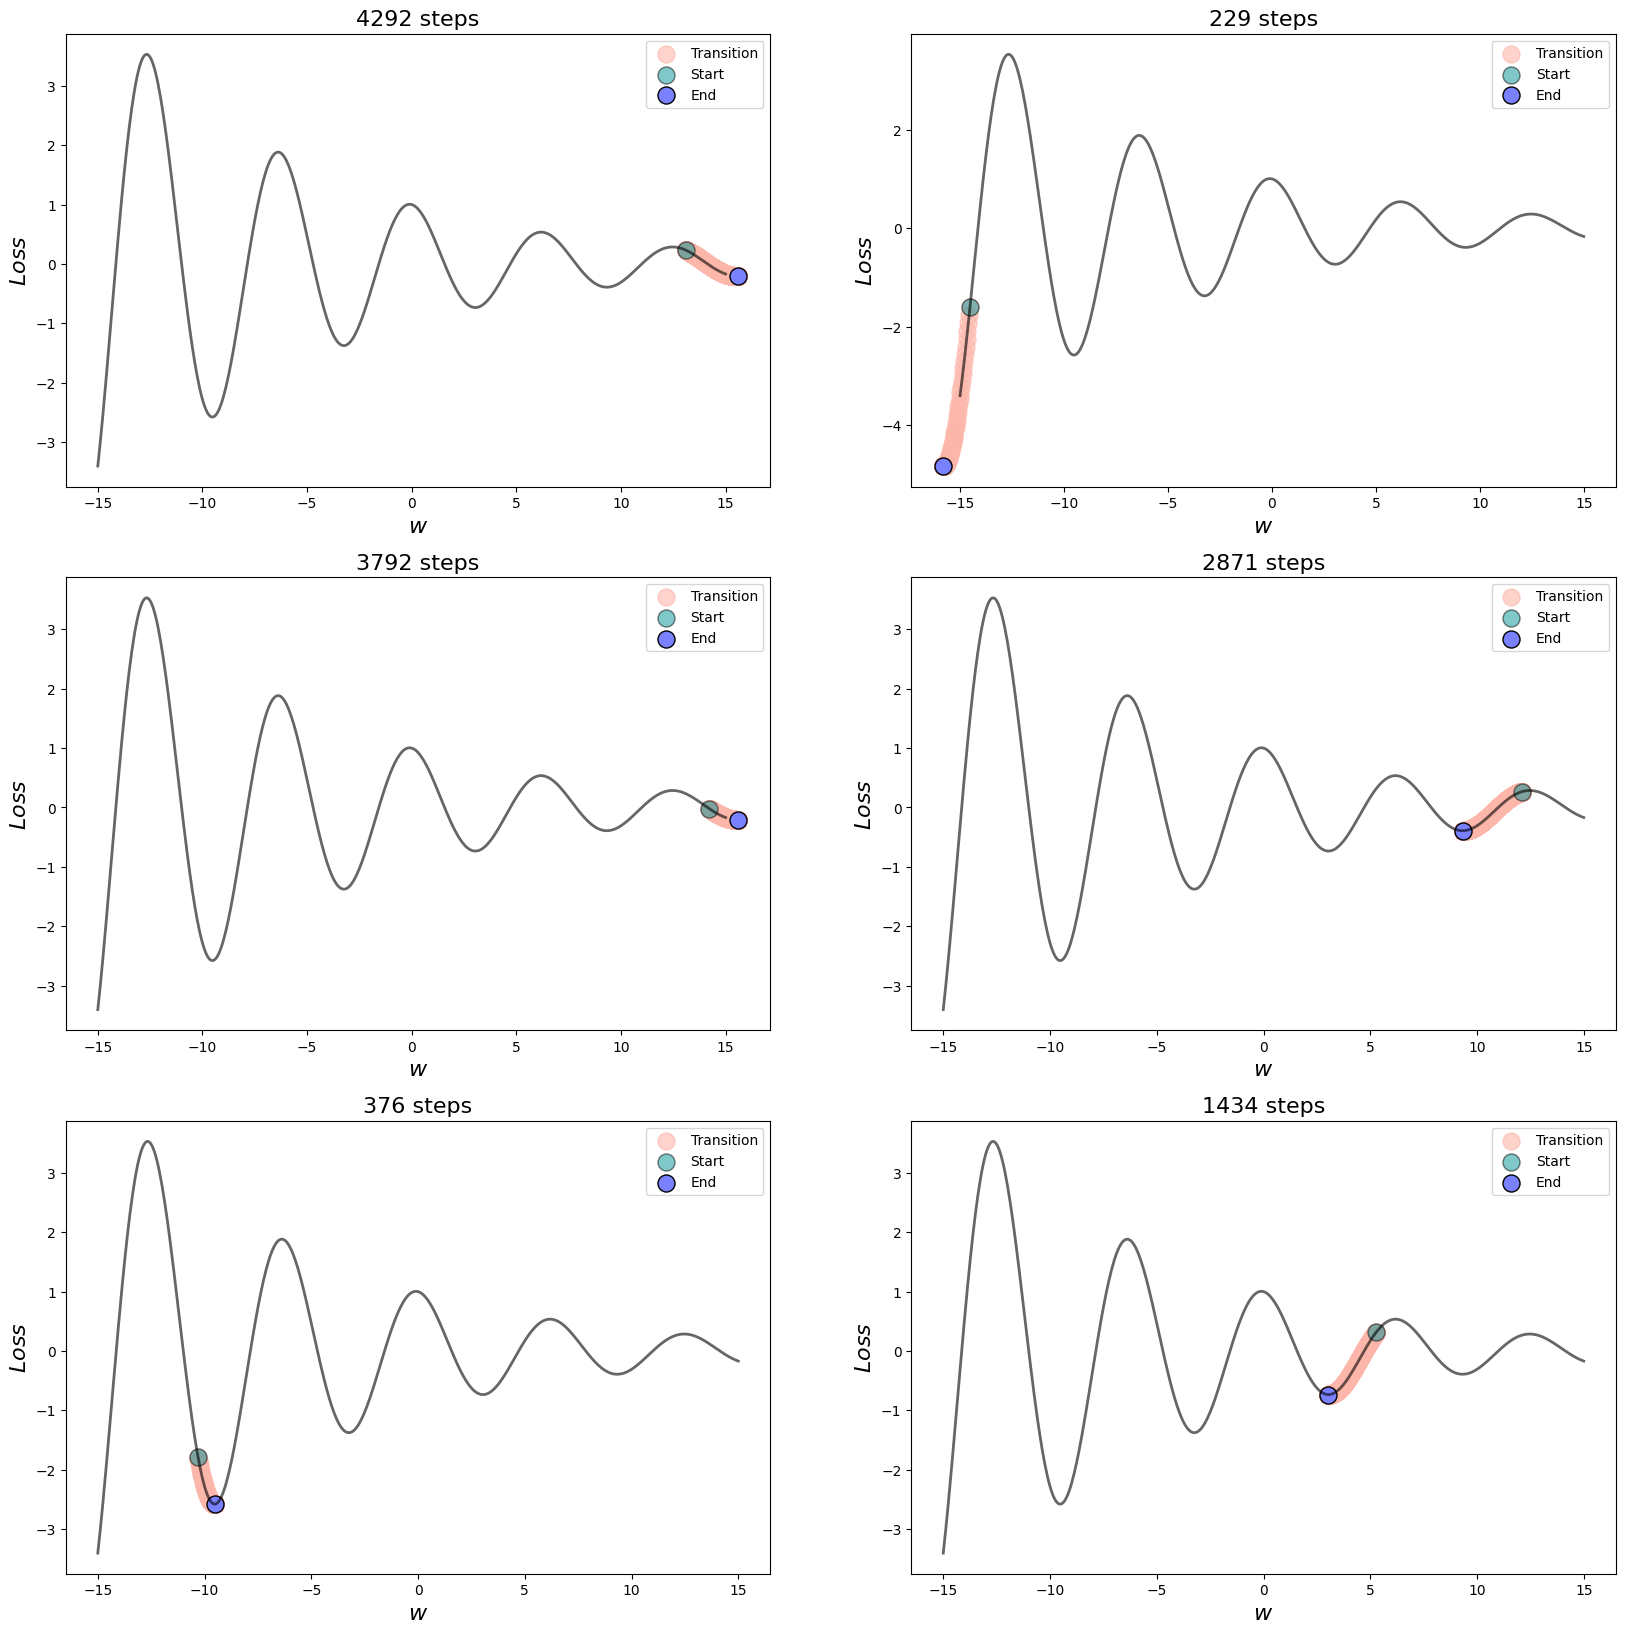

In [8]:
# Select eta value that is less than or equal to 1.
# This is the learning rate.
eta = .01

# Plot the gradient descent starting from 6 random values of W
fig, axes = plt.subplots(3,2, figsize=(20,20))

# Run the loop for the number of plots to make
for ax in axes.ravel():
    
    # Initialise the weights to a random value between -15 and 15 
    # (which are the min and max values used above) 
    W = np.random.uniform(-15,15)
    
    # Get the weights after gradient descent and the number of iterations
    # by calling the gradient_descent function with the initialised 
    # weights and selected epsilon value
    Ws, t = gradient_descent(W, eta)
    
    
    # Use the helper function below to plot how descent is working 
    # after initialising to random weight
    
    # Plot the original data
    ax.plot(w, loss, color='black', alpha=0.6, linewidth=2)
    ax.scatter(np.array(Ws), compute_loss(np.array(Ws)), s=150, label='Transition', color='#FDB6AA', alpha=0.6)
    
    # Plot the starting point
    ax.scatter(Ws[0], compute_loss(Ws[0]), c='#009193', s=150, label='Start', alpha=0.5, edgecolor='black')
    ax.set_title(f'{t} steps', fontsize=16)
    
    # Plot the ending point
    ax.scatter(Ws[-1], compute_loss(Ws[-1]), c='#7A81FF', s=150, label='End',edgecolor='black')
    ax.set_xlabel("$w$", fontsize=16)
    ax.set_ylabel("$Loss$", fontsize=16)
    ax.legend(loc='best');
    